# Parameter Guide

This tutorial explains how to choose and tune BOCPD parameters for your specific application.

## What You'll Learn

- Theoretical foundations: likelihood, hazard, priors, and gap distributions
- How to choose observation models for different data types
- How to set hazard functions based on expected segment lengths
- Hyperparameter tuning strategies
- Visual parameter sensitivity analysis

## We will specifically look at:
- When and how to use Gaussian Normal-Inverse-Gamma as your observation model
- When and how to use Constant-Hazard as your Hazard function
- The effect of Max run length and how to safely estimate it

## Prerequisites

Complete tutorials 01-03 first for foundational understanding.

---

## Setup

Import libraries for experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from fast_bocpd import BOCPD, GaussianNIG, ConstantHazard

print("Libraries loaded successfully")

Libraries loaded successfully


---
## 1. BOCPD Model Components

BOCPD is a **hierarchical Bayesian model** with several interacting components. Understanding these is crucial for proper configuration.

### The Complete Model

At each time $t$, BOCPD tracks:

$$P(r_t, \theta_t \mid x_{1:t})$$

where:
- $r_t$ = run length (time since last changepoint)
- $\theta_t$ = parameters of current segment
- $x_{1:t}$ = observed data

### Key Components

**1. Observation Model (Likelihood)**

How likely is observation $x_t$ given segment parameters $\theta$?

$$p(x_t \mid \theta) \quad \text{— the likelihood function}$$

In our library: `obs_model` parameter (e.g., `GaussianNIG`)

**2. Parameter Prior**

What do we believe about $\theta$ before seeing data?

$$p(\theta) \quad \text{— the prior distribution}$$

In our library: hyperparameters of `obs_model` (e.g., `mu0`, `kappa0`, `alpha0`, `beta0` for Gaussian-NIG)

**3. Hazard Function**

What is the probability of a changepoint given we've been in a segment for $r$ steps?

$$H(r) = P(\text{changepoint at } t \mid r_{t-1} = r) \quad \text{— hazard function}$$

In our library: `hazard` parameter (e.g., `ConstantHazard`)

**4. Gap Distribution**

How long do segments last? The gap $g$ between changepoints has distribution:

$$p(g = k) = H(k-1) \prod_{j=0}^{k-2}(1 - H(j)) \quad \text{— gap distribution}$$

This is **derived from** the hazard function, not specified separately.

### Relationship Between Components

$$\text{Hazard } H(r) \quad \xrightarrow{\text{determines}} \quad \text{Gap distribution } p(g)$$

$$\text{Prior } p(\theta) + \text{Likelihood } p(x \mid \theta) \quad \xrightarrow{\text{Bayes}} \quad \text{Posterior } p(\theta \mid x)$$

These combine in the BOCPD recursion to produce $P(r_t \mid x_{1:t})$.

---
## 2. Observation Models: Choosing the Right Likelihood

The observation model encodes your assumptions about **how data is generated within a segment**.
The choice of observation model should match the **distribution our data is generated from and domain knowledge**.

#### current supported Models:
1. GaussianNIG

Later:

2. Student-t
3. more...

### 2.1 GaussianNIG

**Full name:** Gaussian likelihood with Normal-Inverse-Gamma conjugate prior

**When to use:**
- Data is continuous and roughly symmetric
- Want to detect changes in mean and/or variance
- Need conjugate updates (fast, exact inference)

**Assumptions:**
- Within each segment: $x_t \sim \mathcal{N}(\mu, \sigma^2)$
- Prior on parameters: $(\mu, \sigma^2) \sim \text{NIG}(\mu_0, \kappa_0, \alpha_0, \beta_0)$

**Hyperparameters:**
- `mu0`: Prior mean (where you expect segment means to be)
- `kappa0`: Prior confidence in `mu0` (higher = stronger belief)
- `alpha0`: Shape parameter for variance prior
- `beta0`: Scale parameter for variance prior

**Predictive distribution:**

$$p(x_{t+1} \mid x_{1:t}, r_t = r) = \text{Student-t}(\nu, \mu_r, \sigma_r^2)$$

where parameters are updated from the prior using data in the current segment.

---
### 2.1.1 GaussianNIG Hyperparameters

#### The Prior Structure

**Joint prior:**

$$\sigma^2 \sim \text{Inverse-Gamma}(\alpha_0, \beta_0)$$
$$\mu \mid \sigma^2 \sim \mathcal{N}(\mu_0, \sigma^2/\kappa_0)$$

**Parameters:**
- `mu0`: Prior mean location
- `kappa0`: Number of "pseudo-observations" for mean (confidence)
- `alpha0`: Shape of variance prior
- `beta0`: Scale of variance prior

#### Intuitive Interpretation

**`mu0`:** "I expect segment means around this value"  
**`kappa0`:** "I'm as confident as if I'd seen `kappa0` observations"  
**`alpha0` and `beta0`:** Control prior variance and its uncertainty

**Prior variance:**

$$\mathbb{E}[\sigma^2] = \frac{\beta_0}{\alpha_0 - 1} \quad (\text{for } \alpha_0 > 1)$$


#### Choosing Hyperparameters

**Strategy 1: Weakly Informative (Default)**

```python
GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
```

- `mu0=0`: No strong prior on mean location
- `kappa0=1`: Low confidence (like seeing 1 observation)
- `alpha0=1, beta0=1`: Diffuse prior on variance

**Strategy 2: From Domain Knowledge**

If you know data is "temperature in Celsius, usually 15-25°C":

```python
GaussianNIG(mu0=20.0, kappa0=0.1, alpha0=2.0, beta0=5.0)
```

- `mu0=20`: Center at expected value
- `kappa0=0.1`: Very weak confidence (let data dominate)
- Prior variance ≈ 5 (matches expected range)

**Strategy 3: From Data**

Estimate from historical data:

```python
data_mean = np.mean(data)
data_var = np.var(data)

GaussianNIG(
    mu0=data_mean,
    kappa0=0.1,  # Weak
    alpha0=2.0,
    beta0=data_var
)
```

### 2.1.2 Hyperparameter Sensitivity Analysis

Let's visualize how hyperparameters affect detection.

#### Effect of `mu0`

Does the prior mean matter?

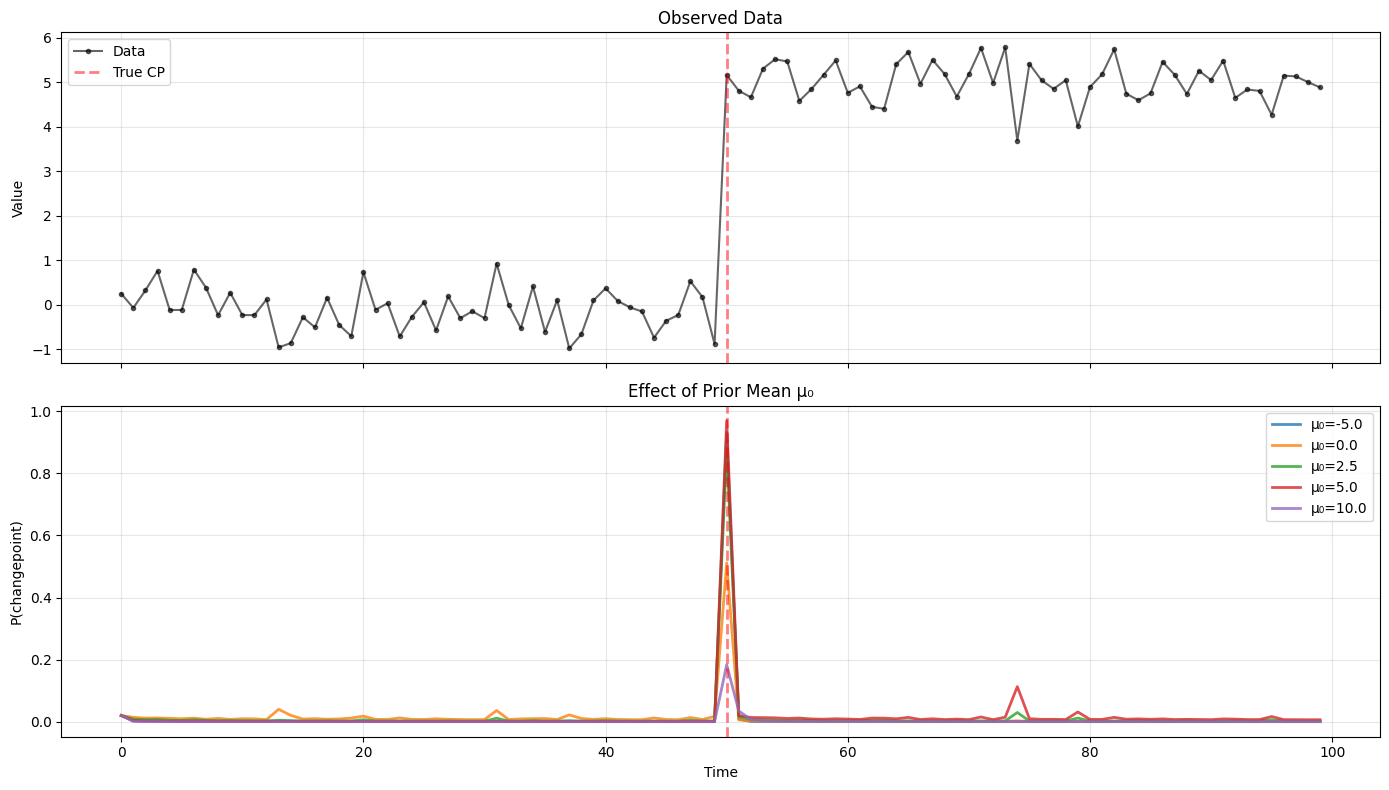

Observation: With weak prior (kappa0=1), mu0 has minimal effect
The algorithm adapts quickly to the data


In [2]:
# Generate data: mean shifts from 0 to 5
np.random.seed(42)
data = np.concatenate([
    np.random.randn(50) * 0.5 + 0.0,
    np.random.randn(50) * 0.5 + 5.0
])

# Try different mu0 values
mu0_values = [-5.0, 0.0, 2.5, 5.0, 10.0]
hazard = ConstantHazard(lambda_=50)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot data
ax1.plot(data, 'o-', alpha=0.6, markersize=3, color='black', label='Data')
ax1.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=2, label='True CP')
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Test each mu0
for mu0 in mu0_values:
    model = GaussianNIG(mu0=mu0, kappa0=1.0, alpha0=1.0, beta0=1.0)
    bocpd = BOCPD(model, hazard, max_run_length=100)
    
    cp_probs = bocpd.batch_update(data)
    ax2.plot(cp_probs, linewidth=2, label=f'μ₀={mu0}', alpha=0.8)

ax2.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('P(changepoint)')
ax2.set_title('Effect of Prior Mean μ₀')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Observation: With weak prior (kappa0=1), mu0 has minimal effect")
print("The algorithm adapts quickly to the data")

#### Effect of Prior Strength (kappa0)

How does confidence in the prior affect detection?

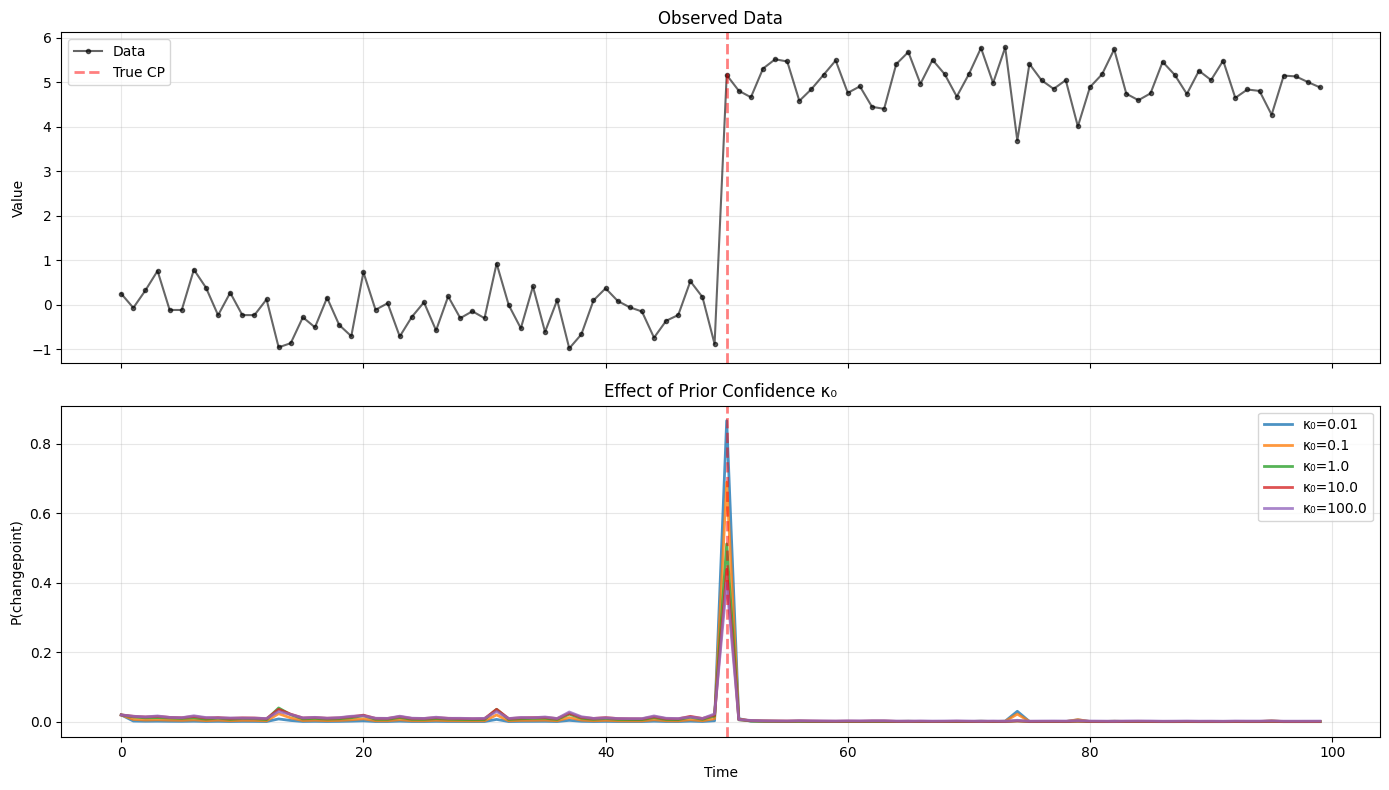

Key insight:
- kappa0=0.01 (very weak): Fast adaptation, may be noisy
- kappa0=1.0 (moderate): Good balance
- kappa0=100 (very strong): Slow adaptation, resists change


In [3]:
# Test different kappa0 values (prior strength)
kappa0_values = [0.01, 0.1, 1.0, 10.0, 100.0]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot data
ax1.plot(data, 'o-', alpha=0.6, markersize=3, color='black', label='Data')
ax1.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=2, label='True CP')
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Test each kappa0
for kappa0 in kappa0_values:
    model = GaussianNIG(mu0=0.0, kappa0=kappa0, alpha0=1.0, beta0=1.0)
    bocpd = BOCPD(model, hazard, max_run_length=100)
    
    cp_probs = bocpd.batch_update(data)
    ax2.plot(cp_probs, linewidth=2, label=f'κ₀={kappa0}', alpha=0.8)

ax2.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('P(changepoint)')
ax2.set_title('Effect of Prior Confidence κ₀')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Key insight:")
print("- kappa0=0.01 (very weak): Fast adaptation, may be noisy")
print("- kappa0=1.0 (moderate): Good balance")
print("- kappa0=100 (very strong): Slow adaptation, resists change")

---
## 3. Hazard Functions: Modeling Segment Lengths

The hazard function $H(r)$ controls **changepoint probability** as a function of run length.

### Current supported Hazard functions:
1. Constant Hazard

Later:

2. Geometric Hazard (Discrete Exponential):
3. Time-Varying Hazard:

### 3.1 ConstantHazard

**Definition:**

$$H(r) = \frac{1}{\lambda} \quad \text{for all } r$$

**Interpretation:** Probability of changepoint is constant over time (memoryless).

**Gap Distribution:** 

$$p(g = k) = \frac{1}{\lambda}\left(1 - \frac{1}{\lambda}\right)^{k-1} \quad \text{(Geometric distribution)}$$

**Expected segment length:** $\mathbb{E}[g] = \lambda$

**Parameter:**
- `lambda_`: Expected number of observations between changepoints

**When to use:**
- No prior knowledge about segment length patterns
- Segments vary considerably in length
- Want simplicity and interpretability
- This is by far the most common Hazard function to use.

**How to set λ:**

1. **From domain knowledge:** "I expect changepoints every ~100 observations" → `lambda_=100`
2. **From data inspection:** Count observations between known changepoints
3. **From cross-validation:** Try multiple values, pick best performance

#### 3.1.1 Visualizing Hazard Functions

Let's see how `lambda_` affects the gap distribution for ConstantHazard.

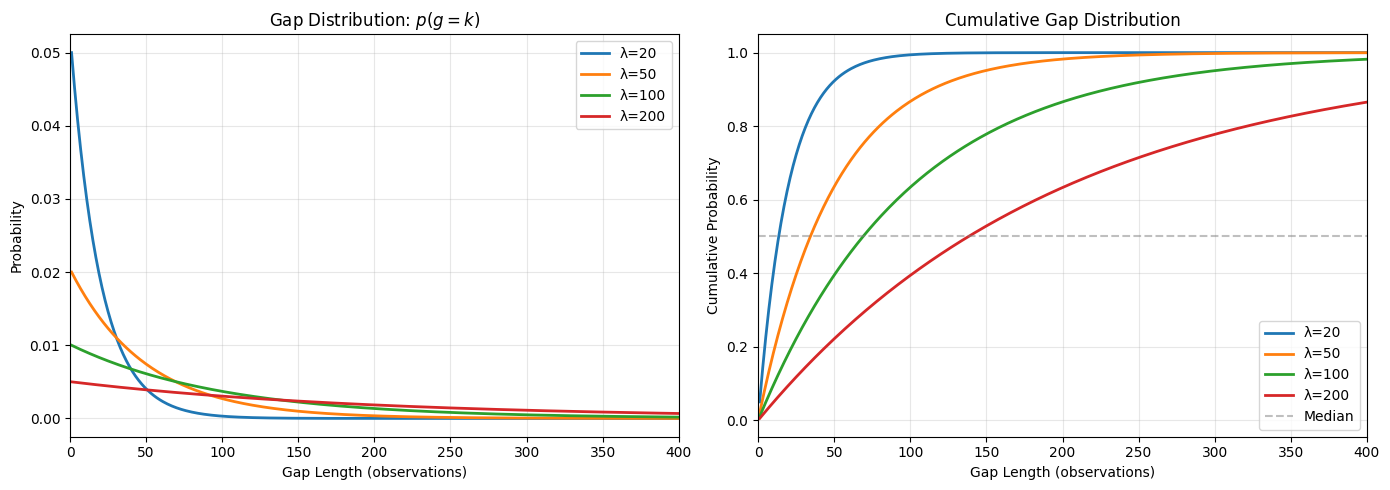

Key observations:
- Larger λ → longer expected segments
- All have geometric (exponential) decay
- Peak probability always at gap=1 for constant hazard


In [4]:
# Compare different lambda values
lambdas = [20, 50, 100, 200]
max_gap = 400

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for lam in lambdas:
    # Gap distribution for constant hazard
    gaps = np.arange(1, max_gap + 1)
    H = 1.0 / lam
    gap_probs = H * (1 - H)**(gaps - 1)
    
    # Plot PMF
    ax1.plot(gaps, gap_probs, label=f'λ={lam}', linewidth=2)
    
    # Plot CDF
    cumulative = np.cumsum(gap_probs)
    ax2.plot(gaps, cumulative, label=f'λ={lam}', linewidth=2)

ax1.set_xlabel('Gap Length (observations)')
ax1.set_ylabel('Probability')
ax1.set_title('Gap Distribution: $p(g = k)$')
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, max_gap)

ax2.set_xlabel('Gap Length (observations)')
ax2.set_ylabel('Cumulative Probability')
ax2.set_title('Cumulative Gap Distribution')
ax2.axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Median')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, max_gap)

plt.tight_layout()
plt.show()

print("Key observations:")
print("- Larger λ → longer expected segments")
print("- All have geometric (exponential) decay")
print("- Peak probability always at gap=1 for constant hazard")

#### 3.1.2 Effect of Hazard Parameter (lambda_)

The hazard controls expected segment length and detection sensitivity.

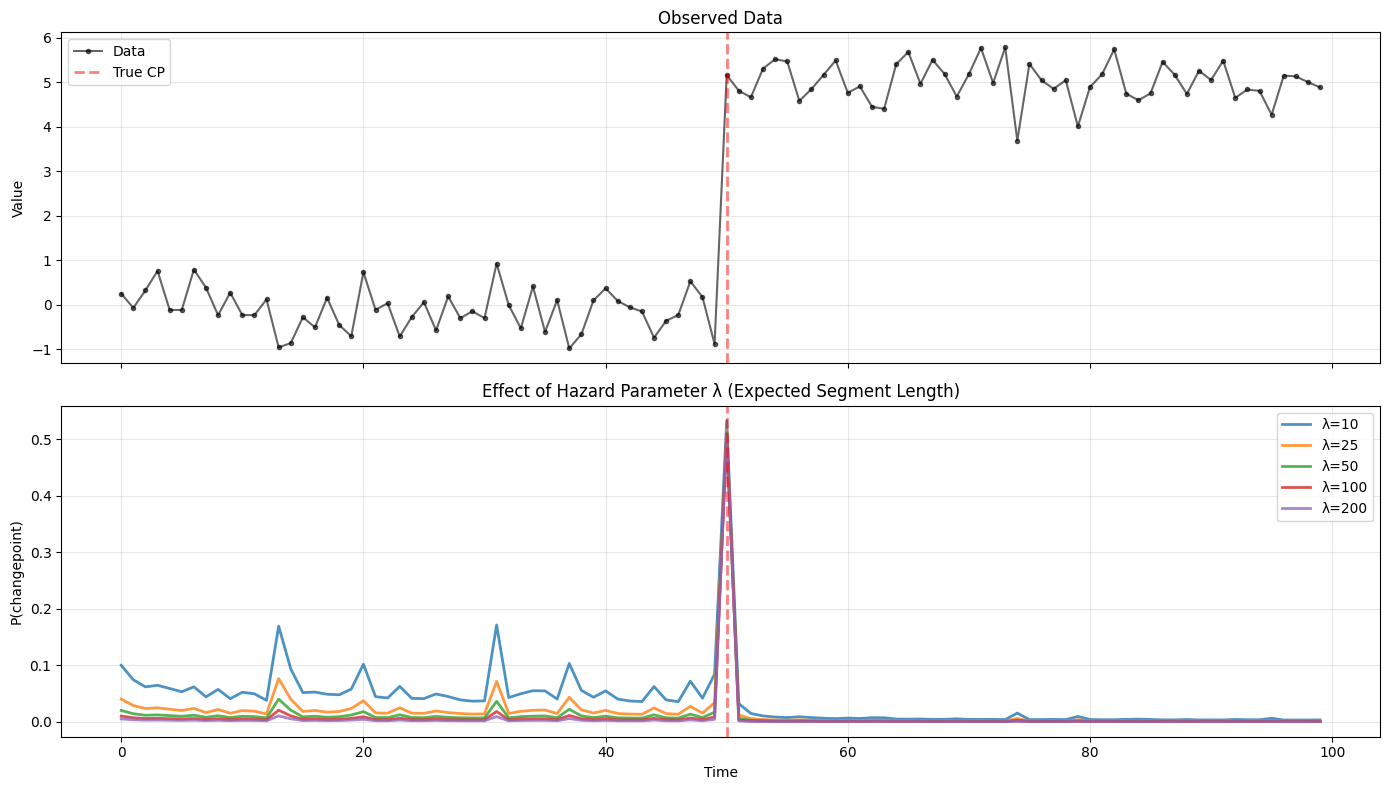

Critical observations:
- λ=10 (short expected length): Many false positives, very sensitive
- λ=50 (matches true length): Good detection
- λ=200 (long expected length): Conservative, may miss changepoints

Rule of thumb: Set λ close to expected segment length


In [5]:
# Test different lambda values
lambda_values = [10, 25, 50, 100, 200]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Plot data
ax1.plot(data, 'o-', alpha=0.6, markersize=3, color='black', label='Data')
ax1.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=2, label='True CP')
ax1.set_ylabel('Value')
ax1.set_title('Observed Data')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Test each lambda
model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)

for lam in lambda_values:
    hazard = ConstantHazard(lambda_=lam)
    bocpd = BOCPD(model, hazard, max_run_length=100)
    
    cp_probs = bocpd.batch_update(data)
    ax2.plot(cp_probs, linewidth=2, label=f'λ={lam}', alpha=0.8)

ax2.axvline(50, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.set_xlabel('Time')
ax2.set_ylabel('P(changepoint)')
ax2.set_title('Effect of Hazard Parameter λ (Expected Segment Length)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Critical observations:")
print("- λ=10 (short expected length): Many false positives, very sensitive")
print("- λ=50 (matches true length): Good detection")
print("- λ=200 (long expected length): Conservative, may miss changepoints")
print("\nRule of thumb: Set λ close to expected segment length")

---
## 4. Effect of max_run_length

The `max_run_length` parameter limits computational cost but affects accuracy.

### What is max_run_length?

BOCPD tracks $P(r_t = r \mid x_{1:t})$ for $r = 0, 1, \ldots, R_{max}$.

**Computational cost:** $O(R_{max}^2)$ per observation  
**Memory:** $O(R_{max})$

### Trade-offs

**Too small:** 
- Fast computation
- May truncate posterior if true run length exceeds $R_{max}$
- Detection degrades for long segments

**Too large:**
- Accurate even for long segments
- Slower, more memory

### Choosing max_run_length

**Rule of thumb:** Set $R_{max} \geq 2\lambda$ (twice expected segment length)

**For safety:** $R_{max} = 3\lambda$ to 5$\lambda$

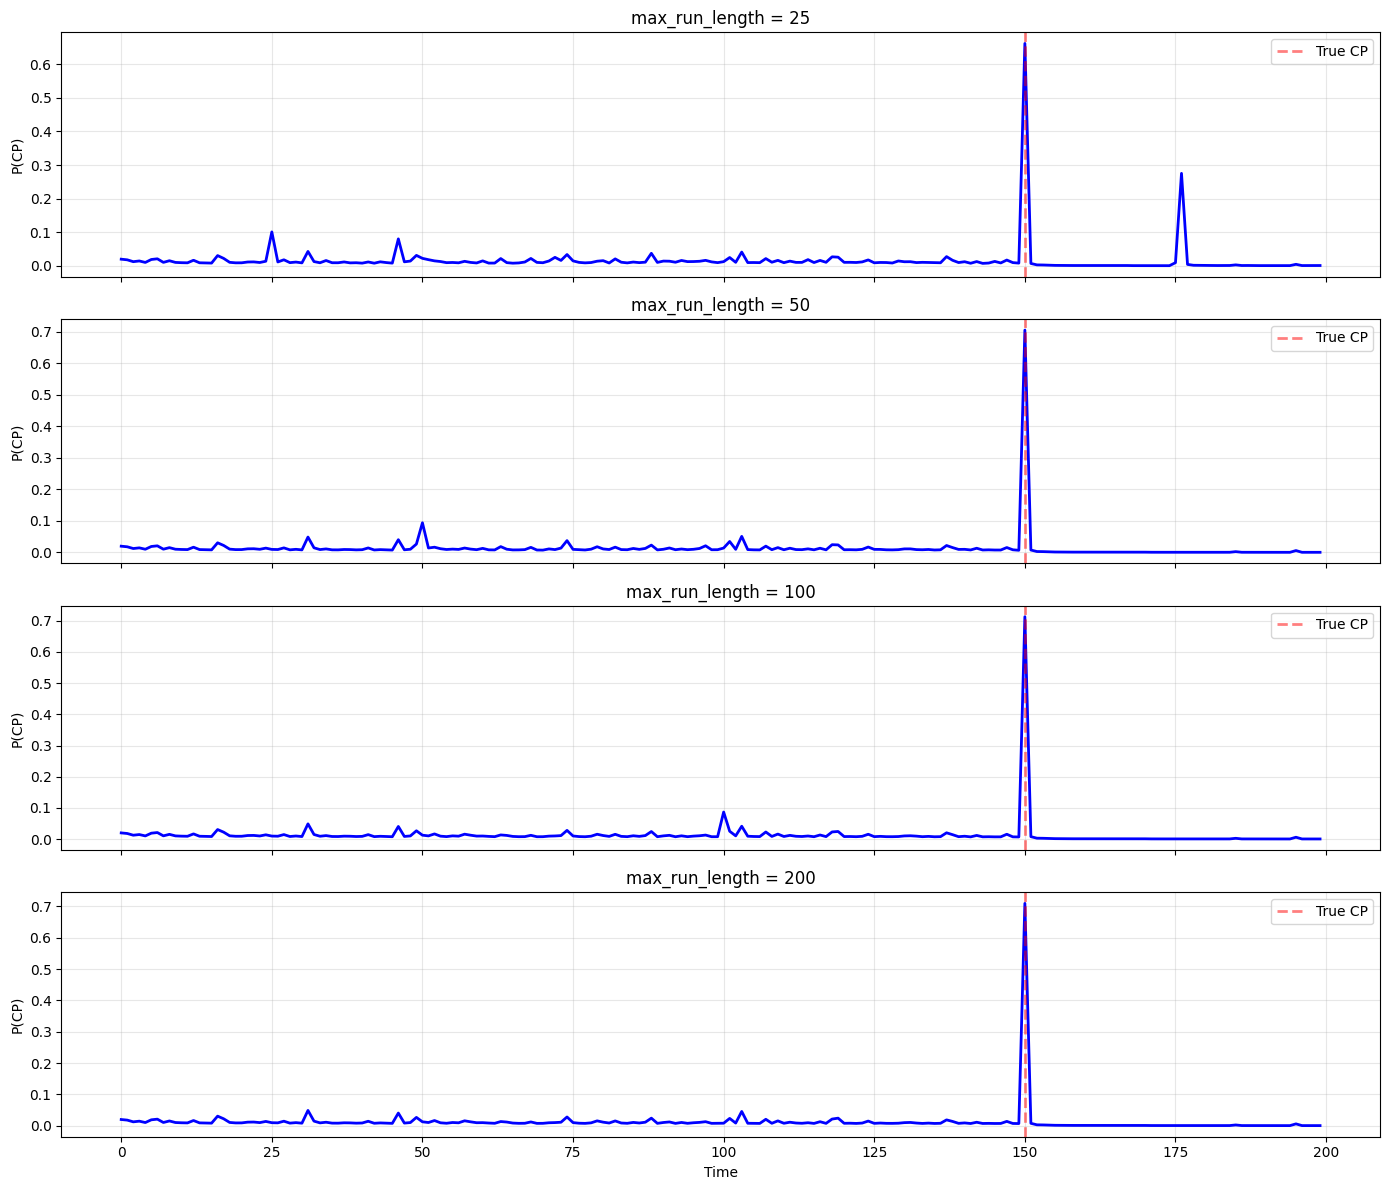

Observation:
- Segment length = 150
- max_run_length < 150: May miss changepoint or have degraded detection
- max_run_length >= 150: Good detection

Recommendation: max_run_length >= 2 * lambda (here: >= 150)


In [6]:
# Test effect of max_run_length
max_r_values = [25, 50, 100, 200]

# Generate data with long first segment
np.random.seed(123)
data_long = np.concatenate([
    np.random.randn(150) * 0.5 + 0.0,  # Long segment
    np.random.randn(50) * 0.5 + 5.0
])

fig, axes = plt.subplots(len(max_r_values), 1, figsize=(14, 12), sharex=True)

model = GaussianNIG(mu0=0.0, kappa0=1.0, alpha0=1.0, beta0=1.0)
hazard = ConstantHazard(lambda_=50)

for i, max_r in enumerate(max_r_values):
    bocpd = BOCPD(model, hazard, max_run_length=max_r)
    cp_probs = bocpd.batch_update(data_long)
    
    ax = axes[i]
    ax.plot(cp_probs, linewidth=2, color='blue')
    ax.axvline(150, color='red', linestyle='--', alpha=0.5, linewidth=2, label='True CP')
    ax.set_ylabel('P(CP)')
    ax.set_title(f'max_run_length = {max_r}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Highlight if detection failed
    if cp_probs[150] < 0.3:
        ax.text(150, 0.5, 'MISSED!', fontsize=12, color='red', 
                ha='center', bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))

axes[-1].set_xlabel('Time')
plt.tight_layout()
plt.show()

print("Observation:")
print(f"- Segment length = 150")
print(f"- max_run_length < 150: May miss changepoint or have degraded detection")
print(f"- max_run_length >= 150: Good detection")
print(f"\nRecommendation: max_run_length >= 2 * lambda (here: >= 150)")

---
## Summary

### Key Takeaways

**1. Model Components**
- **Observation model:** Likelihood function + parameter prior
- **Hazard function:** Controls changepoint probability over time
- **Gap distribution:** Derived from hazard (not set independently)

**2. Currently Available**
- **Observation:** GaussianNIG (continuous data)
- **Hazard:** ConstantHazard (memoryless, geometric gaps)

**3. Parameter Selection**

| Parameter | What It Does | How to Set |
|-----------|-------------|-----------|
| `lambda_` | Expected segment length | From domain knowledge or data |
| `max_run_length` | Computational limit | 3-5× `lambda_` |

**4. Best Practices**
- Standardize data when possible (makes default priors appropriate)
- Set λ ≈ expected segment length
- Use max_run_length ≥ 3λ
- Start with default priors, adjust if needed
- Validate on data with known changepoints

### Next Steps

- **05_advanced_features.ipynb:** Production-ready detection with OnlineChangeDetector
- **06_real_world_us30_volatility.ipynb:** Apply these concepts to real financial data